In [1]:
from PIL import Image
import torch
import torch.nn.functional as F
entity_state_map = {
    "drawer": ["open", "closed"],
}
sample_images = []
sample_solutions = []
validation_images = []
validation_solutions = []
for entity, states in entity_state_map.items():
    for state in states:
        for i in range(10):
            dir = f"../data/samples/front"
            image = Image.open(f"{dir}/{entity}_{state}_{i}.png")
            if i < 5:
                sample_images.append(image)
                sample_solutions.append(state)
            else:
                validation_images.append(image)
                validation_solutions.append(state)

In [15]:
import matplotlib.pyplot as plt

all_labels = list(set(sample_solutions + validation_solutions))
label_to_color = {l: i for i, l in enumerate(sorted(all_labels))}

colors = [label_to_color[l] for l in validation_solutions]

In [ ]:
from heca.environment.scenes.image_extractor import ImageExtractor


extractor = ImageExtractor.get(ageExtractor)

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

In [ ]:
sample_batch = torch.stack([transforms(img) for img in sample_images]) # type: ignore
validation_batch = torch.stack([transforms(img) for img in validation_images])  # type: ignore

with torch.no_grad():
    sample_output = model.forward_features(sample_batch)
    val_output = model.forward_features(validation_batch)
    # output is unpooled, a (1, 261, 4096) shaped tensor

    sample_out = model.forward_head(sample_output, pre_logits=True)
    val_out = model.forward_head(val_output, pre_logits=True)
    # output is a (1, num_features) shaped tensor


# output is a (1, num_features) shaped tensor
print(sample_out.shape)
print(val_out.shape)

torch.Size([10, 768])
torch.Size([10, 768])


In [13]:
import torch
import torch.nn.functional as F
from collections import Counter

train_emb = F.normalize(sample_out, dim=1)
val_emb = F.normalize(val_out, dim=1)

k = 3

predictions = []
confidences = []
max_sims = []
mean_sims = []
correct = []

for i, val_vec in enumerate(val_emb):

    sims = torch.matmul(train_emb, val_vec)
    topk = torch.topk(sims, k=k)

    indices = topk.indices.tolist()
    scores = topk.values.tolist()

    neighbor_labels = [sample_solutions[idx] for idx in indices]

    pred = Counter(neighbor_labels).most_common(1)[0][0]
    confidence = neighbor_labels.count(pred) / k

    predictions.append(pred)
    confidences.append(confidence)

    max_sims.append(scores[0])
    mean_sims.append(sum(scores) / k)

    correct.append(pred == validation_solutions[i])

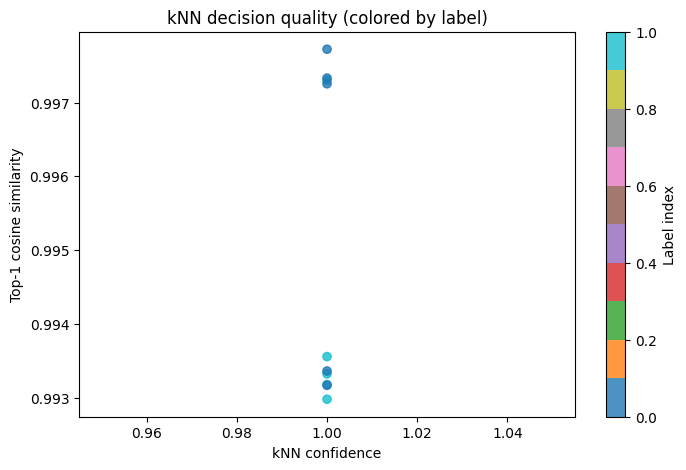

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    confidences,
    max_sims,
    c=[label_to_color[l] for l in validation_solutions],
    cmap="tab10",
    alpha=0.8,
)

plt.xlabel("kNN confidence")
plt.ylabel("Top-1 cosine similarity")
plt.title("kNN decision quality (colored by label)")
plt.colorbar(label="Label index")

plt.show()

In [5]:
correct = sum(pred == gt for pred, gt in zip(predictions, validation_solutions))

acc = correct / len(validation_solutions)

print(f"Accuracy: {acc:.2f}")

Accuracy: 1.00


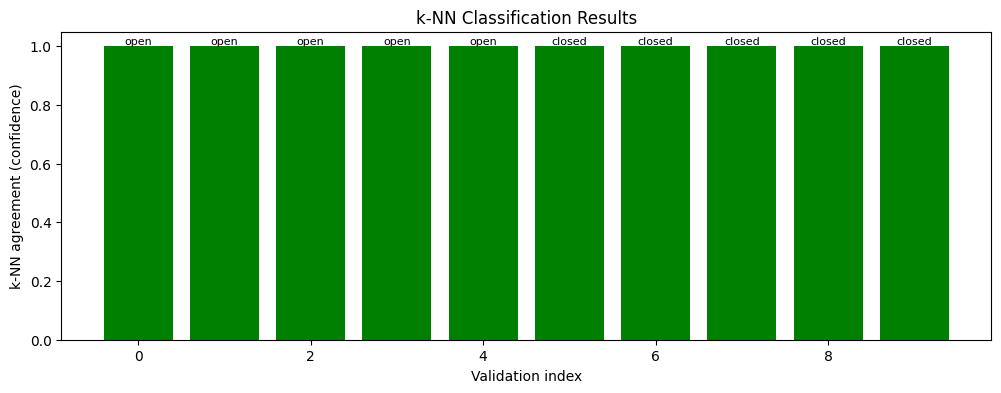

In [7]:
import matplotlib.pyplot as plt
import torch

state_labels = sorted(list(set(sample_solutions)))  # or ["open", "closed"]

label_to_idx = {l: i for i, l in enumerate(state_labels)}

# convert predictions + ground truth
pred_idx = [label_to_idx[p] for p in predictions]
gt_idx = [label_to_idx[g] for g in validation_solutions]

correct = [p == g for p, g in zip(pred_idx, gt_idx)]

# simple confidence: fraction of top-k neighbors matching predicted label
confidences = []

for i, val_vec in enumerate(val_emb):
    sims = torch.matmul(train_emb, val_vec)
    topk = torch.topk(sims, k=k)

    neighbor_labels = [sample_solutions[idx] for idx in topk.indices.tolist()]
    pred_label = predictions[i]
    conf = neighbor_labels.count(pred_label) / k
    confidences.append(conf)

plt.figure(figsize=(12, 4))

for i, (conf, pred, is_correct) in enumerate(zip(confidences, predictions, correct)):
    color = "green" if is_correct else "red"
    plt.bar(i, conf, color=color)
    plt.text(i, conf, pred, ha="center", va="bottom", fontsize=8)

plt.xlabel("Validation index")
plt.ylabel("k-NN agreement (confidence)")
plt.title("k-NN Classification Results")
plt.show()

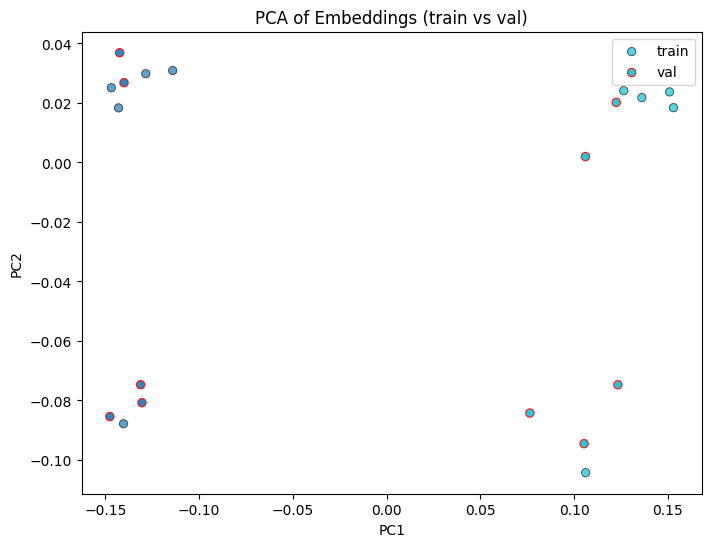

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

# labels
all_labels = sample_solutions + validation_solutions
unique = sorted(set(all_labels))
label_to_color = {l: i for i, l in enumerate(unique)}

train_labels = sample_solutions
val_labels = validation_solutions

# PCA fit on train only
pca = PCA(n_components=2).fit(train_emb.detach().cpu().numpy())

train_2d = pca.transform(train_emb.detach().cpu().numpy())
val_2d = pca.transform(val_emb.detach().cpu().numpy())

# map label -> color index
train_colors = [label_to_color[l] for l in train_labels]
val_colors = [label_to_color[l] for l in val_labels]

plt.figure(figsize=(8, 6))

# train points (black edge)
plt.scatter(
    train_2d[:, 0],
    train_2d[:, 1],
    c=train_colors,
    cmap="tab10",
    edgecolors="black",
    linewidths=0.6,
    alpha=0.7,
    label="train",
)

# val points (red edge)
plt.scatter(
    val_2d[:, 0],
    val_2d[:, 1],
    c=val_colors,
    cmap="tab10",
    edgecolors="red",
    linewidths=0.8,
    alpha=0.9,
    label="val",
)

plt.legend()
plt.title("PCA of Embeddings (train vs val)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()